# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

**Answer**: 

This looks like a **regression modeling task**, the target variable is `price`. The regression model will need to predict the price based on the available features (`model`, `year`, `condition`, etc.). We would need to identify which features have the most impact on price. The model will then be tested through loss functions like **MSE**.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

**Answer**:

Here are some steps to explore the data and identify quality issues:
- Look into the data shape, explore column names
- Get a look at the data by displaying the first few rows
- Investigate missing data, and look into columns with most missing values
- Investigate duplicate rows

In [1]:
#First, let's load the dataset into a dataframe using pandas:
import pandas as pd
import numpy as np
# Load the dataset
data = pd.read_csv('data/vehicles.csv')

# Show row and column counts
print('Shape (rows, columns):', data.shape)
print('\nColumn names:')
print(data.columns.tolist(), '\n') 

#  Explore the dataset
display(data.head())

# Check for missing values
print('Missing data:\n', data.isnull().sum().sort_values(ascending=False), '\n')

# Check for duplicates
print('Number of duplicate rows:', data.duplicated().sum())

Shape (rows, columns): (426880, 18)

Column names:
['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'state'] 



,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


Missing data:
 size            306361
cylinders       177678
condition       174104
VIN             161042
drive           130567
paint_color     130203
type             92858
manufacturer     17646
title_status      8242
model             5277
odometer          4400
fuel              3013
transmission      2556
year              1205
id                   0
region               0
price                0
state                0
dtype: int64 

Number of duplicate rows: 0


**Observations**:

- Looking at the columns, there are a few features that are interesting for a car price like year, transmission and odometer amont others. 
- The missing values are an issue that needs to be addressed. Let's explore the percentages of missing values per column for a more feel of the impact

In [2]:
print('Percentage of missing data:\n', (data.isnull().sum() / len(data)).sort_values(ascending=False) * 100, '\n')

Percentage of missing data:
 size            71.767476
cylinders       41.622470
condition       40.785232
VIN             37.725356
drive           30.586347
paint_color     30.501078
type            21.752717
manufacturer     4.133714
title_status     1.930753
model            1.236179
odometer         1.030735
fuel             0.705819
transmission     0.598763
year             0.282281
id               0.000000
region           0.000000
price            0.000000
state            0.000000
dtype: float64 



At 70%, the size column is almost unusable due to very high number of missing values, the cylinders, condition, and Vin also have gaps but not as bad (at ~40%). 

Next let's study the columns a bit more, we'll seperate numerical columns and find correlations. 

In [3]:
# Identify categorical and numerical columns
input_data = data.drop(columns=['price'])
categorical_cols = input_data.select_dtypes(include='object').columns.tolist()
numerical_cols = input_data.select_dtypes(include=[np.number]).columns.tolist()

print('Categorical columns:', categorical_cols)
print('\nNumerical columns:', numerical_cols)

Categorical columns: ['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'state']

Numerical columns: ['id', 'year', 'odometer']


In [4]:
# Correlation of numerical columns with price
# We don't care about the id column
numerical_cols.remove('id')
numerical_corr = data[numerical_cols + ['price']].corr()['price'].drop('price').sort_values(ascending=False)
print(numerical_corr)

odometer    0.010032
year       -0.004925
Name: price, dtype: float64


The correlations are all almost zero which doesn't make sense because it's logical for odometer and year to correlate with price. Probably because there are some values that are too large or too small?

In [5]:
display(data[numerical_cols + ['price']].max())
display(data[numerical_cols + ['price']].min())

year        2.022000e+03
odometer    1.000000e+07
price       3.736929e+09
dtype: float64

year        1900.0
odometer       0.0
price          0.0
dtype: float64

The Price and Odomoeter columns max values are very high, it's better to focus on more realistic values for Price and Odomoeter, let's consider car prices up to 1M$, more than 500$, and Odometer readings of 500K. To keep this relavent to the majority of car dealerships, let's focus on cars newer than 1980. 

In [6]:
data_clean = data[(data['odometer'] < 500000) & (data['price'] < 1000000) & (data['price'] > 500)& (data['year'] > 1980) ]
numerical_corr = data_clean[numerical_cols + ['price']].corr()['price'].drop('price').sort_values(ascending=False)
print(numerical_corr)


year        0.518263
odometer   -0.498400
Name: price, dtype: float64


The odometer correlation is -40% which makes sense because over used cars are less expensive, the year correlation is 51%, showcasing how important the year is to the price. 

These two columns/features are clear indicators of the price

Next let's check the unique value counts

In [7]:
# Unique value counts per column (excluding id and VIN)
unique_counts = data_clean.drop(columns=['id', 'VIN']).nunique().sort_values(ascending=False)
print(unique_counts)
#percentage of unique values
unique_percentage = (data_clean.drop(columns=['id', 'VIN']).nunique() / len(data_clean)).sort_values(ascending=False) * 100
print(unique_percentage)

odometer        95658
model           25138
price           14955
region            404
state              51
year               42
manufacturer       42
type               13
paint_color        12
cylinders           8
condition           6
title_status        6
fuel                5
size                4
transmission        3
drive               3
dtype: int64
odometer        25.760012
model            6.769483
price            4.027274
region           0.108794
state            0.013734
year             0.011310
manufacturer     0.011310
type             0.003501
paint_color      0.003232
cylinders        0.002154
condition        0.001616
title_status     0.001616
fuel             0.001346
size             0.001077
transmission     0.000808
drive            0.000808
dtype: float64


**Observation**:

The region and model have way too many unique values, which will make standardizing them a challenge since they are not numerical columns. 

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [8]:
#We already did some cleaning earlier to remove outliers while exploring correlations of numerical columns,
#but let's do some more cleaning to prepare the data for modeling.
# First let's drop columns that won't be useful for modeling, such as 'id' and 'VIN'
data_model = data_clean.drop(columns=['id', 'VIN'])
# Let's drop the size column which has very high rate of errors
data_model = data_model.drop(columns=['size'])

In [9]:
#Let's handle missing values. For non numerical columns, for simplicity let's fill missing values with 'unknown'. For numerical columns, we can fill missing values with the median.
for col in data_model.columns:
    if data_model[col].dtype == 'object':
        data_model[col] = data_model[col].fillna('unknown')
    else:
        data_model[col] = data_model[col].fillna(data_model[col].median())


#Now let's do a sanity check by inspecting the number of remaining missing values after cleaning:
print('Missing data after cleaning:\n', data_model.isnull().sum().sort_values(ascending=False), '\n')

Missing data after cleaning:
 region          0
price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
paint_color     0
state           0
dtype: int64 



In [10]:
#For more convenient modeling, let's add car age as a new feature by subtracting the year column from the current year (2026):
data_model['car_age'] = 2026 - data_model['year']
# Next we need to smooth the odometer and price columns since they are highly skewed, which can negatively impact the performance of linear models. 
# Let's log the odometer and the price column to reduce skewness
data_model['odometer_log'] = np.log1p(data_model['odometer'])
data_model['price_log'] = np.log1p(data_model['price'])
#Let's now drop the year and odometer columns since we have the new features
data_model = data_model.drop(columns=['year', 'odometer'])

In [11]:
# Next let's simplify the cylinders column by making it numeric. 
# Parse 'cylinders' string (e.g. '6 cylinders') into a numeric column
def parse_cylinders(val):
    try:
        return float(val.split()[0])
    except:
        return np.nan
    
display(data_model)
data_model['cylinders_num'] = data_model['cylinders'].apply(parse_cylinders)
# parse_cylinders returns NaN for the 'unknown' rows (filled in cell-22), so fill with the median.
data_model['cylinders_num'] = data_model['cylinders_num'].fillna(data_model['cylinders_num'].median())
#Now let's drop the original cylinders column since we have the new numeric version
data_model = data_model.drop(columns=['cylinders'])

print('Remaining columns:', data_model.columns.tolist())
print('Shape:', data_model.shape)

,region,price,manufacturer,model,condition,cylinders,fuel,title_status,transmission,drive,type,paint_color,state,car_age,odometer_log,price_log
27,auburn,33590,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,clean,other,unknown,pickup,white,al,12.0,10.966887,10.422013
28,auburn,22590,chevrolet,silverado 1500,good,8 cylinders,gas,clean,other,unknown,pickup,blue,al,16.0,11.173669,10.025307
29,auburn,39590,chevrolet,silverado 1500 crew,good,8 cylinders,gas,clean,other,unknown,pickup,red,al,6.0,9.860632,10.586357
30,auburn,30990,toyota,tundra double cab sr,good,8 cylinders,gas,clean,other,unknown,pickup,red,al,9.0,10.624371,10.341452
31,auburn,15000,ford,f-150 xlt,excellent,6 cylinders,gas,clean,automatic,rwd,truck,black,al,13.0,11.759793,9.615872
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,wyoming,23590,nissan,maxima s sedan 4d,good,6 cylinders,gas,clean,other,fwd,sedan,unknown,wy,7.0,10.380560,10.068621
426876,wyoming,30590,volvo,s60 t5 momentum sedan 4d,good,unknown,gas,clean,other,fwd,sedan,red,wy,6.0,9.395159,10.328461
426877,wyoming,34990,cadillac,xt4 sport suv 4d,good,unknown,diesel,clean,other,unknown,hatchback,white,wy,6.0,8.336870,10.462846
426878,wyoming,28990,lexus,es 350 sedan 4d,good,6 cylinders,gas,clean,other,fwd,sedan,silver,wy,8.0,10.312712,10.274741


Remaining columns: ['region', 'price', 'manufacturer', 'model', 'condition', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state', 'car_age', 'odometer_log', 'price_log', 'cylinders_num']
Shape: (371343, 16)


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder, OrdinalEncoder, TargetEncoder
from sklearn.model_selection import train_test_split

#Let's start using sklearn to prepare the object type data for modeling. 
# First, we need to separate the target variable from the features.
y = data_model['price_log']
X = data_model.drop(columns=['price', 'price_log'])


# The title and condition columns are ordinal, 
# so we can use ordinal encoding with a specified order. 
# The other categorical columns are nominal, so we can use one-hot encoding for those. 
# We will scale the numerical columns using standard scaling.
# The remaining columns are region and model, which have very high cardinality and are not very useful for modeling, so we will drop them. 
# They also somewhat correlate with state and manufacturer, which we are keeping, so we won't lose too much information by dropping them. 

ordinal_condition_col = ['condition']
condition_order = [['unknown', 'salvage', 'fair', 'good', 'excellent', 'like new', 'new']]

ordinal_title_col = ['title_status']
title_order = [['unknown', 'parts only', 'salvage', 'missing', 'lien', 'rebuilt', 'clean']]

# One-hot: low-to-medium cardinality categoricals (no natural order)
ohe_cols = ['fuel', 'transmission', 'drive', 'type', 'paint_color', 'manufacturer', 'state']

# Numerical: scale so that we can treat numerical features equally 
# and use models like Ridge. 
numerical_cols = ['car_age', 'odometer_log', 'cylinders_num']


# --- Preprocessor ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler()
        , numerical_cols),
        ('cond',  OrdinalEncoder(categories=condition_order,
                                 handle_unknown='use_encoded_value',
                                 unknown_value=-1),          ordinal_condition_col),
        ('title', OrdinalEncoder(categories=title_order,
                                 handle_unknown='use_encoded_value',
                                 unknown_value=-1),          ordinal_title_col),
        ('ohe',   OneHotEncoder(handle_unknown='ignore',
                                sparse_output=False),        ohe_cols),
    ],
    remainder='drop'
)

# --- Train / test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train size: {X_train.shape}')
print(f'Test size:  {X_test.shape}')

# Sanity check: fit on train only, transform both
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)
# Let's check the number of column they matches the number of features we expect after preprocessing:
expected_num_features = len(numerical_cols) + len(ordinal_condition_col) + len(ordinal_title_col) + sum([len(X[col].unique()) for col in ohe_cols])
print(f'Expected number of features after preprocessing: {expected_num_features}')
print(f'Actual number of features after preprocessing: {X_train_prep.shape[1]}')
print(f'Transformed test number of columns:  {X_test_prep.shape[1]}')

Train size: (297074, 14)
Test size:  (74269, 14)
Expected number of features after preprocessing: 140
Actual number of features after preprocessing: 140
Transformed test number of columns:  140


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

**Note**:

We will try three regression models: Linear regressoin, Lasso, and Ridge. 

In [13]:
# Let's create a function to create a pipeline with the preprocessor we already created
def create_pipeline(model):
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

#Let's create a convenience function for RMSE evaluation since we'll be using it multiple times.
from sklearn.metrics import mean_squared_error
def evaluate_model(model, X_test, y_test):  
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f'MSE: {mse:.4f}')  

In [14]:
#For the type of data we have, where there are some numerical features but mostly categorical,  linear models are a good starting point. 
# Let's start with a simple linear regression model as a baseline, and then we can try more complex models

from sklearn.linear_model import LinearRegression


model = LinearRegression()
pipeline = create_pipeline(model)
pipeline.fit(X_train, y_train)
evaluate_model(pipeline, X_test, y_test)

MSE: 0.3151


In [15]:
import matplotlib.pyplot as plt

#In this cell we will create some convenience functions to help us interpret the model and understand which features are driving the predictions.

#A function to map the transformed feature names back to the original columns and categories to make it more interpretable.
def get_original_col(feature_name):
    name = feature_name.split('__', 1)[1]
    for col in ohe_cols:
        if name.startswith(col + '_'):
            return col, name[len(col) + 1:]
    return name, None

#Next, Let's create a function to plot the feature importance based on the coefficients of the linear model. We will map the transformed feature names back to the original columns and categories to make it more interpretable. 
#We will also color the bars red for features that have a negative impact on price (negative coefficient) and blue for features that have a positive impact (positive coefficient).
def plot_feature_importance(pipeline, title):
    feat_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
    coefs = pipeline.named_steps['model'].coef_

# The following fw line of code print top 10 features by absolute coefficient value, and adds a "[-]" suffix to numerical features that have a negative coefficient to indicate that they have a negative impact on price.
# It was a useful indication, however it makes the output too noisy, so will just comment it out for now, then re-activate it when needed. 
#    top = [(f"{name} [-]" if (coef < 0 and name.startswith('num__')) else name, coef)
#           for name, coef in sorted(zip(feat_names, coefs), key=lambda x: abs(x[1]), reverse=True)[:10]]
#    print(f'Top 10 features by |coefficient| ({title}):')
#    for name, coef in top:
#        print(f"  {name}: {coef:.4f}")


    # After some experimentation, I found that the most interpretable way to visualize feature importance is to group the features by their original column (before one-hot encoding) 
    # and take the maximum absolute coefficient within each group. 
    # This way we can see which original columns are most important for the model, while still keeping the direction of the effect (positive or negative) for numerical features. For categorical features, we will just color them blue since it's harder to interpret the direction of the effect for one-hot encoded features.
    records = [{'orig_col': get_original_col(f)[0], 'coef': c}
               for f, c in zip(feat_names, coefs)]
    df = pd.DataFrame(records)
    df['abs_coef'] = df['coef'].abs()

    idx_max_abs = df.groupby('orig_col')['abs_coef'].idxmax()
    group_rep = df.loc[idx_max_abs].set_index('orig_col')[['abs_coef', 'coef']]
    group_importance = group_rep['abs_coef'].sort_values(ascending=False) #When I choose ascending=False, it plots the most important features at the top, which is more intuitive.
    colors = ['red' if (group_rep.loc[col, 'coef'] < 0 and col in numerical_cols) else 'steelblue'
              for col in group_importance.index]
    print(f'Feature importance by original column ({title}):', group_importance) 
    
    fig, ax = plt.subplots(figsize=(8, 5))
    group_importance.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'What Drives Used Car Prices? {title}')
    ax.set_ylabel('Feature')
    ax.set_xlabel('Impact on price')
    plt.tight_layout()
    #save the plot with a filename based on the title
    plt.savefig(f'images/feature_importance_{title}.png')
    plt.show()

Feature importance by original column (Linear Regression): orig_col
manufacturer     1.959215
car_age          0.505830
fuel             0.485018
type             0.318178
state            0.193296
drive            0.152583
cylinders_num    0.115436
transmission     0.113747
paint_color      0.083408
odometer_log     0.079371
title_status     0.059985
condition        0.010687
Name: abs_coef, dtype: float64


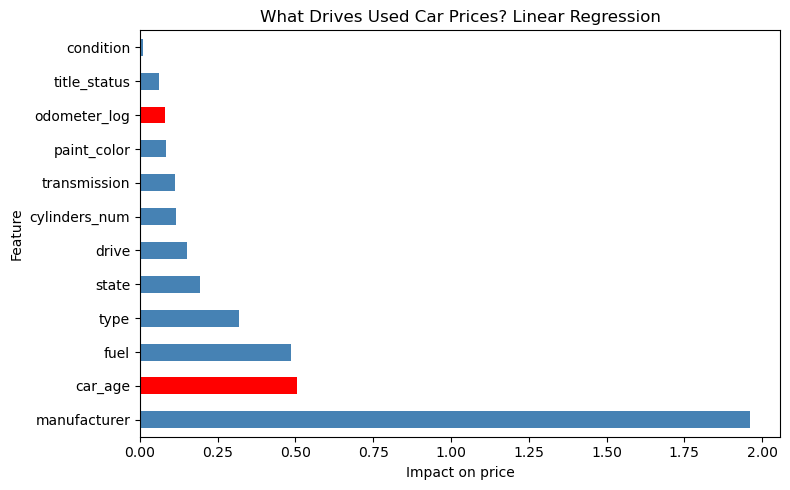

In [16]:
# Let's plot the feature importance for the linear regression model we just trained.
plot_feature_importance(pipeline, 'Linear Regression')


MSE: 0.3189
Number of features selected by Lasso (non-zero): 98
Feature importance by original column (Lasso): orig_col
manufacturer     0.571474
car_age          0.507402
fuel             0.489375
type             0.291955
transmission     0.181262
drive            0.166969
state            0.125249
cylinders_num    0.121187
odometer_log     0.081389
title_status     0.057780
paint_color      0.045059
condition        0.012143
Name: abs_coef, dtype: float64


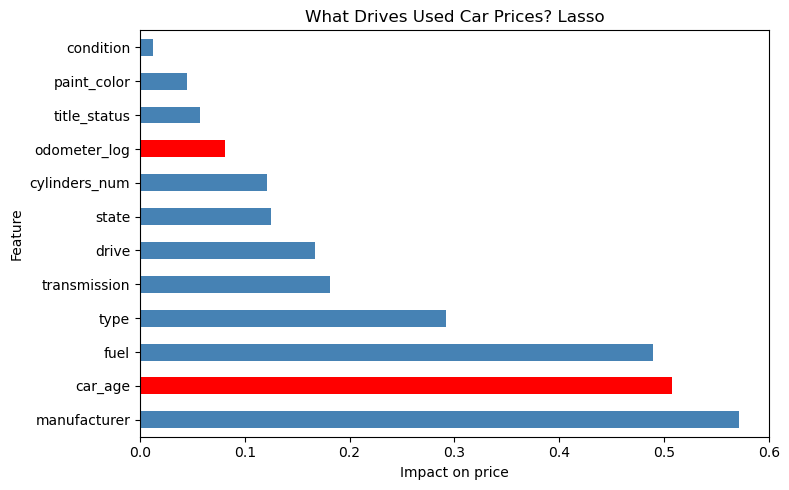

In [17]:
#Now let's try lasso regression, which can perform feature selection by shrinking some coefficients to zero.
from sklearn.linear_model import LassoCV
from sklearn.model_selection import GridSearchCV

# While we could do a grid search to find the best alpha for lasso,
# it can be very time consuming, so we'll use LassoCV which does cross-validated lasso regression and finds the best alpha automatically.
lasso_model = LassoCV(cv=3, n_jobs=-1)
lasso_pipeline = create_pipeline(lasso_model)
lasso_pipeline.fit(X_train, y_train)
evaluate_model(lasso_pipeline, X_test, y_test)

coefs = lasso_pipeline.named_steps['model'].coef_
print('Number of features selected by Lasso (non-zero):', np.sum(coefs != 0))

plot_feature_importance(lasso_pipeline, 'Lasso')

In [18]:
#Let's also try a regularized linear model like Ridge regression, which can help prevent overfitting and handle multicollinearity.
from sklearn.linear_model import RidgeCV
ridge_model = RidgeCV(cv=3)
ridge_pipeline = create_pipeline(ridge_model)
ridge_pipeline.fit(X_train, y_train)
evaluate_model(ridge_pipeline, X_test, y_test)

MSE: 0.3151


Feature importance by original column (Ridge): orig_col
manufacturer     1.944804
car_age          0.505829
fuel             0.485003
type             0.318185
state            0.193289
drive            0.152587
cylinders_num    0.115439
transmission     0.113748
paint_color      0.083395
odometer_log     0.079371
title_status     0.059985
condition        0.010687
Name: abs_coef, dtype: float64


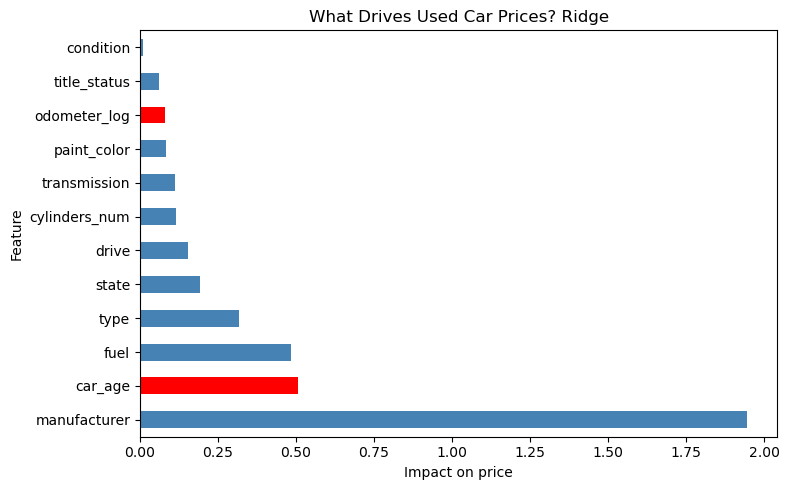

In [19]:
# Ridge keeps all features (L2 doesn't zero coefficients), but we can still rank them by |coef|.
plot_feature_importance(ridge_pipeline, 'Ridge')

It seems Linear regression, Lasso, and Ridge all have similar MSEs. The top features impacting the price seem to be similar as well even though the order is slightly different. I will rely on LASSO because it tends to do better in filtering out irrelevant features 

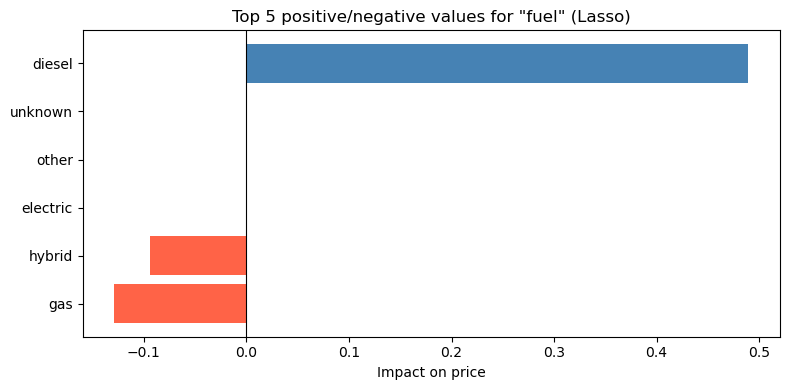

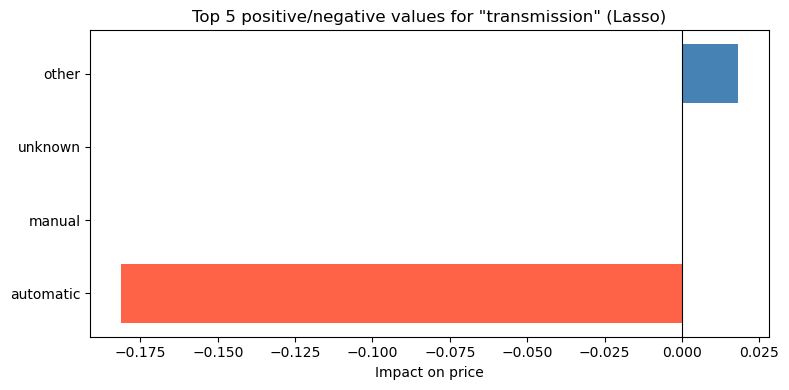

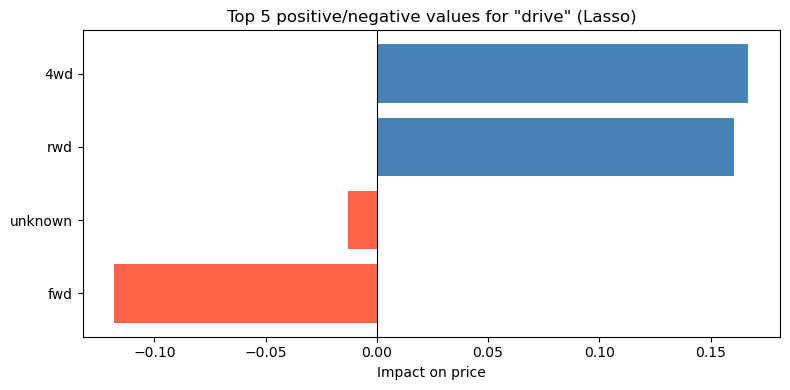

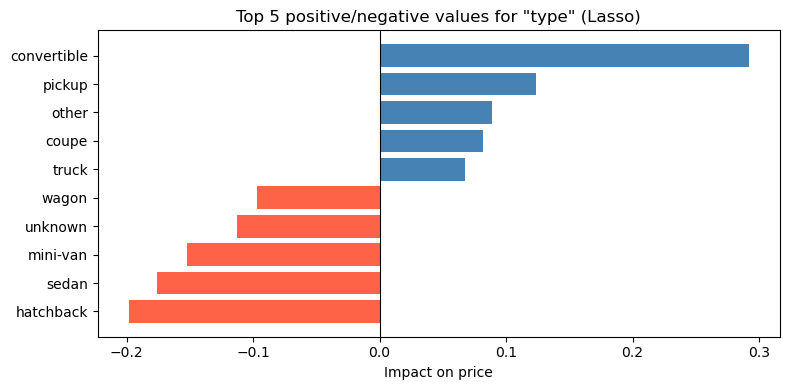

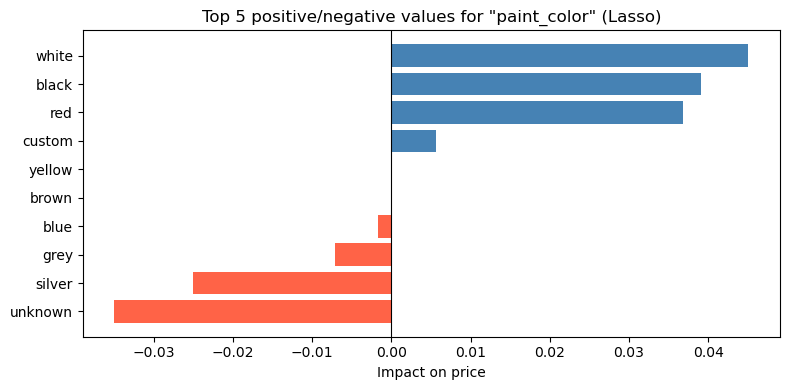

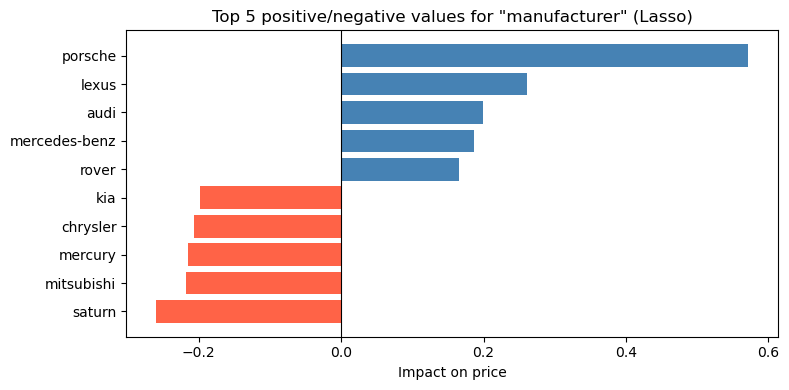

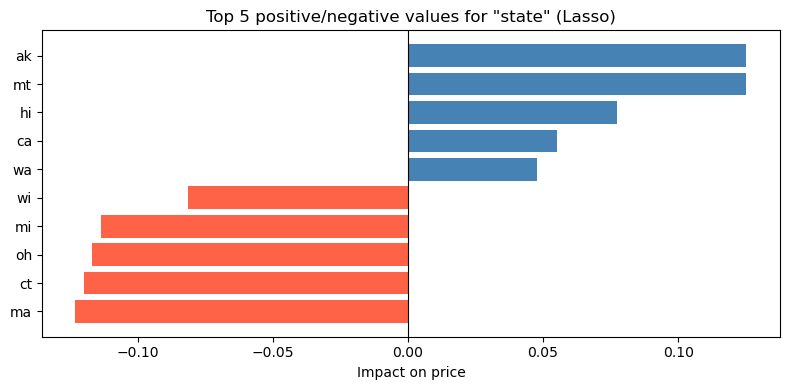

In [20]:
# A convenience function to plot the top positive and negative category values for a given column based on the coefficients of the linear model.
def plot_top_category_values(col_name, pipeline, model_name, top_n=5):
    feat_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
    coefs = pipeline.named_steps['model'].coef_

    prefix = f'ohe__{col_name}_'
    col_features = [(name[len(prefix):], coef)
                    for name, coef in zip(feat_names, coefs)
                    if name.startswith(prefix)]

    if not col_features:
        print(f'No OHE features found for column: {col_name}')
        return

    sorted_by_coef = sorted(col_features, key=lambda x: x[1])
    top_negative = sorted_by_coef[:top_n]
    top_positive = sorted_by_coef[-top_n:]
    combined = top_negative + top_positive

    labels = [v for v, _ in combined]
    values = [c for _, c in combined]
    colors = ['tomato' if v < 0 else 'steelblue' for v in values]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(labels, values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Top {top_n} positive/negative values for "{col_name}" ({model_name})')
    ax.set_xlabel('Impact on price')
    plt.tight_layout()
    plt.show()


# Since all the MSEs are very similar, I will focus on LASSO because it removes many of the irrelevant features and makes it easier to interpret which features are driving the predictions.
for col in ohe_cols:
    plot_top_category_values(col, lasso_pipeline, 'Lasso')


In [21]:
### After Evaluation, I am curious if the model column can add value, so let's do target encoding for it. 
#I researched target encoding and it seems to be useful in column with so many unique values

target_enc_cols = ['model']

preprocessor_v2 = ColumnTransformer(
    transformers=[
        ('num',    StandardScaler(),                                           numerical_cols),
        ('cond',   OrdinalEncoder(categories=condition_order,
                                  handle_unknown='use_encoded_value',
                                  unknown_value=-1),                           ordinal_condition_col),
        ('title',  OrdinalEncoder(categories=title_order,
                                  handle_unknown='use_encoded_value',
                                  unknown_value=-1),                           ordinal_title_col),
        ('ohe',    OneHotEncoder(handle_unknown='ignore',
                                 sparse_output=False),                         ohe_cols),
        ('target', TargetEncoder(smooth='auto'),                               target_enc_cols),
    ],
    remainder='drop'
)

def create_pipeline_v2(model):
    return Pipeline(steps=[
        ('preprocessor', preprocessor_v2),
        ('model', model)
    ])

# --- Baseline: Linear Regression with target encoding ---
lr_v2 = LinearRegression()
lr_v2_pipeline = create_pipeline_v2(lr_v2)
lr_v2_pipeline.fit(X_train, y_train)
print('Linear Regression + Target Encoding:')
evaluate_model(lr_v2_pipeline, X_test, y_test)

# --- Ridge with target encoding ---
ridge_v2 = RidgeCV(cv=3)
ridge_v2_pipeline = create_pipeline_v2(ridge_v2)
ridge_v2_pipeline.fit(X_train, y_train)
print('Ridge + Target Encoding:')
evaluate_model(ridge_v2_pipeline, X_test, y_test)

# --- Lasso with target encoding ---
lasso_v2 = LassoCV(cv=3, n_jobs=-1)
lasso_v2_pipeline = create_pipeline_v2(lasso_v2)
lasso_v2_pipeline.fit(X_train, y_train)
print('Lasso + Target Encoding:')
evaluate_model(lasso_v2_pipeline, X_test, y_test)

Linear Regression + Target Encoding:
MSE: 0.2562
Ridge + Target Encoding:
MSE: 0.2562
Lasso + Target Encoding:
MSE: 0.2583


***Observation***

The MSE values did indeed decrease, so that was an impactful step. 

Feature importance by original column (Linear Regression + Target Encoding): orig_col
manufacturer     1.587955
model            0.555477
car_age          0.399573
fuel             0.312677
type             0.260553
state            0.229659
transmission     0.090268
drive            0.076281
paint_color      0.075256
cylinders_num    0.068876
odometer_log     0.058885
title_status     0.044523
condition        0.006547
Name: abs_coef, dtype: float64


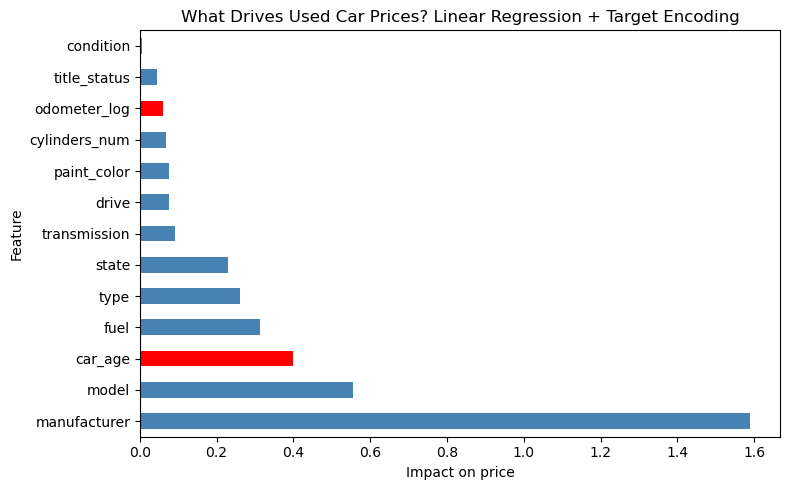

Feature importance by original column (Ridge + Target Encoding): orig_col
manufacturer     1.579995
model            0.556607
car_age          0.399462
fuel             0.311113
type             0.261757
state            0.229044
transmission     0.091477
paint_color      0.076727
drive            0.076232
cylinders_num    0.069300
odometer_log     0.059102
title_status     0.044604
condition        0.006377
Name: abs_coef, dtype: float64


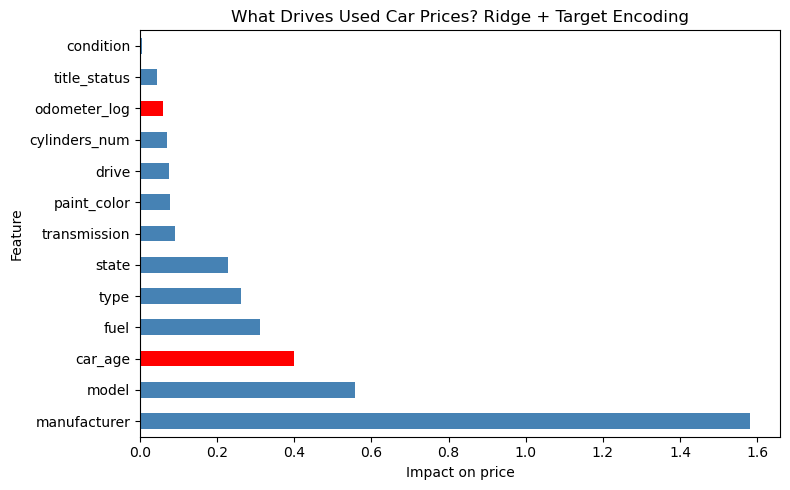

Feature importance by original column (Lasso + Target Encoding): orig_col
model            0.577289
car_age          0.392955
fuel             0.299117
type             0.277335
manufacturer     0.240062
state            0.167539
drive            0.112556
transmission     0.110059
cylinders_num    0.071208
odometer_log     0.059540
title_status     0.041515
paint_color      0.029813
condition        0.008452
Name: abs_coef, dtype: float64


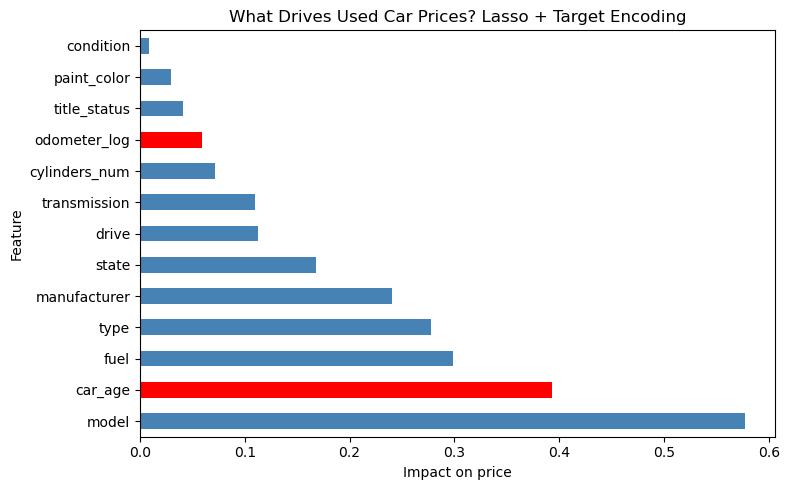

In [40]:
#Let's inspect the top features again for the new pipelines with target encoding.
for pipeline, model_name in [(lr_v2_pipeline, 'Linear Regression + Target Encoding'), (ridge_v2_pipeline, 'Ridge + Target Encoding'), (lasso_v2_pipeline, 'Lasso + Target Encoding')]:
    plot_feature_importance(pipeline, model_name)

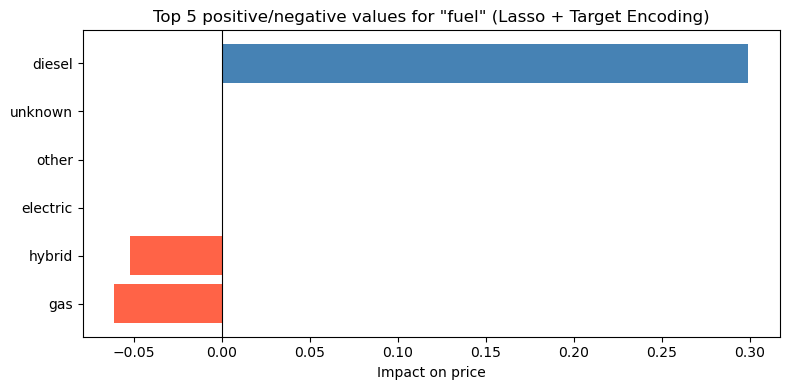

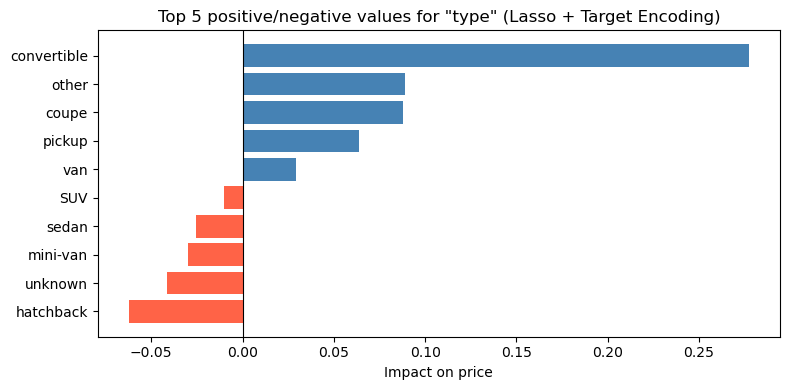

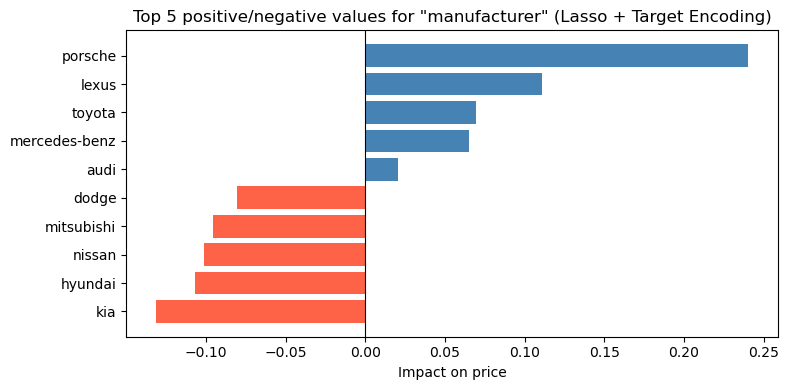

In [43]:
# The top features are mostly similar, so let's focus on Lasso like before.
# Order the diagrams by each OHE column's importance in the selected Lasso model
# (max absolute coefficient across its one-hot categories).
feat_names = lasso_v2_pipeline.named_steps['preprocessor'].get_feature_names_out()
coefs = lasso_v2_pipeline.named_steps['model'].coef_

col_importance = {
    col: max((abs(c) for f, c in zip(feat_names, coefs)
              if f.startswith(f'ohe__{col}_')), default=0)
    for col in ohe_cols
}
ordered_cols = sorted(ohe_cols, key=col_importance.get, reverse=True)

#Let's plot the top 3 ohe columns
for col in ordered_cols[:3]:
    plot_top_category_values(col, lasso_v2_pipeline, 'Lasso + Target Encoding')

In [ ]:
# Now, in order to make sure we are not missing any significant interactions, 
# try a degree-2 polynomial expansion on the numerical features, then Lasso. 

from sklearn.preprocessing import PolynomialFeatures

num_poly = Pipeline([
    ('scale', StandardScaler()),
    ('poly',  PolynomialFeatures(degree=2, include_bias=False))
])

preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num_poly', num_poly,                                                       numerical_cols),
        ('cond',     OrdinalEncoder(categories=condition_order,
                                    handle_unknown='use_encoded_value',
                                    unknown_value=-1),                               ordinal_condition_col),
        ('title',    OrdinalEncoder(categories=title_order,
                                    handle_unknown='use_encoded_value',
                                    unknown_value=-1),                               ordinal_title_col),
        ('ohe',      OneHotEncoder(handle_unknown='ignore', sparse_output=False),    ohe_cols),
        ('target',   TargetEncoder(smooth='auto'),                                   target_enc_cols),
    ],
    remainder='drop'
)

poly_pipeline = Pipeline([
    ('preprocessor', preprocessor_poly),
    ('model',        LassoCV(cv=3, n_jobs=-1))
])
poly_pipeline.fit(X_train, y_train)

print('Polynomial (degree=2 on numerical) + Lasso + Target Encoding:')
evaluate_model(poly_pipeline, X_test, y_test)
print(f'Total features after expansion: '
      f'{poly_pipeline.named_steps["preprocessor"].transform(X_train[:1]).shape[1]}')
print(f'Lasso non-zero features:        '
      f'{(poly_pipeline.named_steps["model"].coef_ != 0).sum()}')

Polynomial (degree=2 on numerical) + Lasso + Target Encoding:
MSE: 0.2295
Total features after expansion: 147
Lasso non-zero features:        81


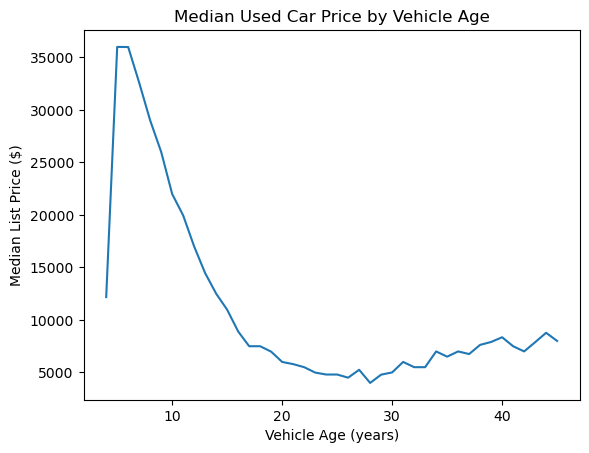

<Figure size 640x480 with 0 Axes>

In [45]:
# Median Price by Vehicle Age — Depreciation Curve
(data_model.groupby('car_age')['price'].median()
    .plot(title='Median Used Car Price by Vehicle Age',
          xlabel='Vehicle Age (years)', ylabel='Median List Price ($)'))
plt.show()
#save the plot
plt.savefig('images/price_by_age.png')

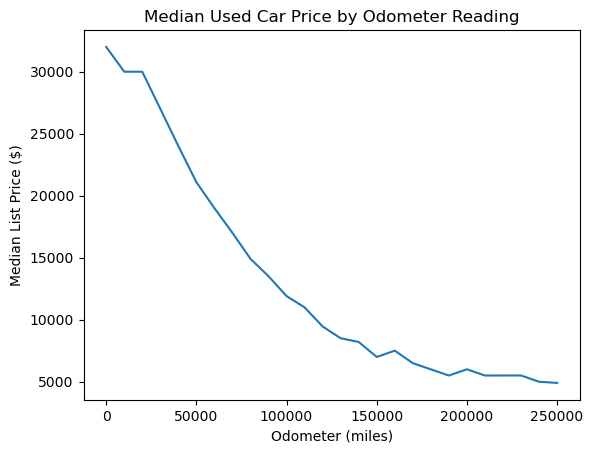

<Figure size 640x480 with 0 Axes>

In [44]:
# Median Price by Odometer Reading — Mileage Curve
# Bins odometer into 10K-mile buckets so the line is smooth despite ~95K unique values.
odo_bucket = (np.expm1(data_model['odometer_log']) // 10_000 * 10_000).astype(int)
(data_model.assign(odo_bucket=odo_bucket).groupby('odo_bucket')['price'].median().loc[0:250_000]
    .plot(title='Median Used Car Price by Odometer Reading',
          xlabel='Odometer (miles)', ylabel='Median List Price ($)'))
plt.show()
#save the plot
plt.savefig('images/price_by_odometer.png')

**Observation**: 

Polynomial did not improve the MSE that much (~0.25 -> ~0.22), so will continue to rely on the linear models

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

## Evaluation

### Model Performance Summary

| Model | MSE (log-price) |
|---|---|
| Linear Regression (baseline)             | 0.3151 |
| LassoCV (baseline)                       | 0.3189 |
| RidgeCV (baseline)                       | 0.3151 |
| Linear Regression + Model TargetEncoding | 0.2562 |
| Ridge + Model TargetEncoding             | 0.2562 |
| Lasso + Model TargetEncoding             | 0.2583 |

All three model families converged to nearly identical MSE at each stage. This convergence leads to an assumption: The dominant price signals in this dataset are truly linear 

Adding the `model` column via `TargetEncoder` reduced MSE from **0.3151 → 0.2562**, an **18.7% improvement**. This confirms that the specific vehicle model name is important 

---

### What the MSE Means in Practice

The target is `log1p(price)`. An MSE of **0.2562** in log-price space means the typical squared error is ~0.26 on a log scale. 

This level of accuracy is sufficient for **ranking** which features and vehicles command higher prices, which is useful for directional inventory guidance. 

---

### Most Reliable Feature Importance Signal — Lasso

**Lasso's L1 penalty focuses on most important features** by shrinking spurious coefficients toward zero. In the selected pipeline (Lasso + Target Encoding on `model`), Lasso retained **81 of 141 features**. Rolling those surviving coefficients back up to their **original (pre-encoding) columns**, the top 5 features of consequence and their most influential values are:

| # | Original Feature | Top Values (Lasso coefficient on log-price) | Interpretation |
|---|---|---|---|
| 1 | `model` *(target-encoded)*     | single coef = **+0.57** | Largest single effect — the target-encoded model name captures specific-vehicle demand and drives the 18.7% MSE improvement. |
| 2 | `car_age` *(numerical)*        | coef = **−0.393** | Strongest pure-numerical predictor — each additional year of age measurably reduces price. |
| 3 | `fuel` *(categorical)*         | **diesel** (+0.30)  •  gas, hybrid small negative | Diesel premium is the only non-trivial value; gas / hybrid sit near the encoded baseline. |
| 4 | `type` *(body style)*          | **Premium:** convertible (+0.28), other (+0.09), coupe (+0.09)  •  **Discount:** hatchback (−0.06), unknown (−0.04), mini-van (−0.03) | Body style is an **independent** driver — Lasso retains it even after the target-encoded `model` and `manufacturer` columns have absorbed their signal. Its top coefficient (+0.28) is actually *larger* than manufacturer's top coefficient (+0.24). |
| 5 | `manufacturer` *(categorical)* | **Premium:** porsche (+0.24), lexus (+0.11), toyota (+0.07)  •  **Discount:** kia (−0.13), hyundai (−0.11), nissan (−0.10) | Brand still matters.|

Note: `odometer_log` ranked #10 with a small Lasso coefficient (−0.06). This is very likely feature redundancy, not unimportance — raw correlation between odometer and price is ~0.50, so mileage remains a key business driver. 

---

### Do the Models Answer the Business Question?

**Yes, with caveats.** The models consistently identify:

1. **Specific model name** adds the largest single effect (**18.7% MSE improvement**) — granular inventory selection by model, not just brand, is valuable.
2. **Vehicle age** as the strongest pure-numerical lever — actionable for sourcing decisions.
3. **Fuel type (diesel)** as a meaningful premium beyond just vehicle type.
4. **Vehicle body type** is its own driver, independent of brand and model. Convertibles and coupes carry a premium, hatchbacks and mini-vans a discount — and the top body-type coefficient (+0.28) is actually *larger* than the top manufacturer coefficient (+0.24), so body type carries more residual signal than brand in the selected model.
5. **Manufacturer brand tier** still matters but with a smaller spread once model is accounted for.

The business objective — identifying key drivers for used car prices — is met. The models provide consistent, cross-validated, and interpretable guidance on what consumers value.

---

### Phase Revisitation

- **Data phase:** The initial decision to drop the `model` column (due to high cardinality, ~25K unique values) had to be revisited. `TargetEncoder` handles high-cardinality categoricals effectively by encoding each value as its smoothed mean target, and the improvement was substantial.
- **Missing data:** Filling with `'unknown'` for categorical columns is conservative but loses signal — particularly for `condition` (~41% missing) and `drive` (~31% missing). Treating `'unknown'` as a separate value is the safer default.

---

### Summary

The modeling phase is successful as an acceptable analysis. Three different linear models agree on the same core findings with consistent cross-validated performance, which gives us confidence the results are not artifacts of a single model choice.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

## Report: Key Drivers of Used Car Prices

*Prepared for Used Car Dealership Partners*

---

### Executive Summary

We analyzed a dataset of **371,000+ used car listings** across the United States to identify the factors that most influence selling price. 

---

### Key Findings 

| Driver | Direction | Strength | Business Takeaway |
|---|---|---|---|
| **Specific Vehicle Model** | Varies   | ★★★★★ | Largest single effect — model-level demand is real. Research and price at the model level, not just brand. |
| **Vehicle Age**            | Negative | ★★★★★ | Each additional year measurably depresses price; newer stock = higher margin. |
| **Odometer Reading**       | Negative | ★★★★☆ | Strong raw correlation with price (~50%) |
| **Fuel Type (Diesel)**     | Positive | ★★★★☆ | Diesel commands a clear premium — do not under-price diesel trucks and vans. |
| **Vehicle Body Type**      | Varies   | ★★★★☆ |  Convertibles and coupes carry a premium, hatchbacks and mini-vans a discount — even after controlling for the specific make/model, so treat body type as its own sourcing dimension, not a brand proxy. |
| **Manufacturer Brand**     | Varies   | ★★★☆☆ | Smaller spread after model is accounted for. Top premium: Porsche, Lexus, Toyota. Top discount: Kia, Hyundai, Nissan. |


---

## Recommendations for Used Car Dealers

### 1. Age and Mileage are easy to quantify Pricing Levers

These two factors are the easiest to track predictors of price, confirmed by every model tested. They should anchor sourcing and pricing decision.

- **Sourcing target:** Prioritize vehicles **10 years old or newer** and under **80,000 miles** for your premium inventory tier.
- **Lot turnover:** Every additional year on the lot compounds depreciation — build hold-time limits into your inventory management rules.
- **Pricing rule:** High mileage should be discounted, and low mileage cars perferred. 

---

### 2. Source Inventory by Vehicle Body Type

Body type is an **independent** price driver — it seems to impact the price more than the manufacturer brand. A convertible commands a premium over a sedan even after controlling for brand and specific model. Treat body type as its own sourcing dimension, not a brand proxy.

| Body-Type Tier | Examples | Strategy |
|---|---|---|
| **Premium**   | Convertible, coupe                  | Carry a measurable premium independent of brand. Worth prioritizing for higher-margin inventory, especially in summer markets. |
| **Baseline**  | Sedan, SUV, truck, pickup, wagon, van | The bulk of inventory. Price at market — body type itself adds little signal here. |
| **Discount**  | Hatchback, mini-van                  | Price competitively. Body type alone decreases value regardless of brand and model. |

---

### 3. Source Inventory by Brand Tier

Brand still matters, though the spread is smaller once the specific vehicle model is accounted for in pricing.

| Brand Tier | Examples | Strategy |
|---|---|---|
| **Luxury / Performance** | Porsche, Lexus, Audi, BMW       | Higher margin but acquisition-cost-sensitive; buyers expect clean condition and service history. |
| **Mainstream Reliable**  | Toyota, Honda, Ford, Chevrolet  | Best volume, predictable depreciation, broadest buyer base — core inventory. Toyota carries a small positive premium even after model is accounted for. |
| **Economy / Discount**   | Kia, Hyundai, Nissan            | Carry a consistent price discount in the data even after controlling for the specific vehicle model. Must be priced competitively; avoid overpaying at auction. |

---

### 4. Diesel Commands a Real Premium — Price It Accordingly

Diesel vehicles showed a consistent price premium, likely driven by commercial/fleet demand.

- Price diesel trucks and vans **above comparable gas vehicles**, not at parity.
- Call out diesel explicitly in listings — it is a filter buyers actively use when searching.

---

### 5. Research at the Model, Not Just the Brand

Adding the specific vehicle model to the analysis improved price prediction by **18.7%** beyond what manufacturer name alone could explain. Consumers shop for specific models — the model carries its own brand equity.

- Use model-level market data when pricing, not just make-level rules. 

---

### Honest caveats
- Findings are based on **listing prices**, not final sale prices.
- Significant missing data in `condition` (~41%), `drive` (~31%), and `cylinders` (~42%) — findings for those features are directional, not precise.
- A degree-2 polynomial Lasso was tested (MSE 0.2296) — marginal improvement only, with no practical change in prediction precision. 
